Limitation of Bag of n-grams

1. As n increased, dimensionality, sparcity also increses.
2. Doesn't address out of vocabulary problem.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
v.fit(["Thor Hacthodavala is lokking for a job"])

v.vocabulary_

{'thor': 5, 'hacthodavala': 1, 'is': 2, 'lokking': 4, 'for': 0, 'job': 3}

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer(ngram_range=(1,2))
v.fit(["Thor Hacthodavala is lokking for a job"])
v.vocabulary_

{'thor': 9,
 'hacthodavala': 2,
 'is': 4,
 'lokking': 7,
 'for': 0,
 'job': 6,
 'thor hacthodavala': 10,
 'hacthodavala is': 3,
 'is lokking': 5,
 'lokking for': 8,
 'for job': 1}

Bi-gram CountVectorizer

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer(ngram_range=(2,2))
v.fit(["Thor Hacthodavala is lokking for a job"])
v.vocabulary_

{'thor hacthodavala': 4,
 'hacthodavala is': 1,
 'is lokking': 2,
 'lokking for': 3,
 'for job': 0}

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hacthodavala is lokking for a job"])
v.vocabulary_

{'thor': 12,
 'hacthodavala': 2,
 'is': 5,
 'lokking': 9,
 'for': 0,
 'job': 8,
 'thor hacthodavala': 13,
 'hacthodavala is': 3,
 'is lokking': 6,
 'lokking for': 10,
 'for job': 1,
 'thor hacthodavala is': 14,
 'hacthodavala is lokking': 4,
 'is lokking for': 7,
 'lokking for job': 11}

In [6]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [7]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    
    for token in doc:
        if token.is_stop or token.is_punct:
            continue 
        filtered_tokens.append(token.lemma_)
        
    return " ".join(filtered_tokens)

print(preprocess("Thor ate pizza"))
print(preprocess("Loki is eating pizza"))


thor eat pizza
Loki eat pizza


In [8]:
corpus_processed = [preprocess(text) for text in corpus]
corpus_processed

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [9]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [10]:
v.transform(["Thor ate pizza"]).toarray()

array([[0, 0, 0, 0, 0, 1, 0, 1, 0]])

In [11]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [12]:
import pandas as pd

df = pd.read_json("news_dataset.json")

print(df.shape)

df.head() 

(12695, 2)


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [13]:
df.category.value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [14]:
min_samples = 1381

df_business = df[df.category == "BUSINESS"].sample(min_samples, random_state = 2022)
df_sports = df[df.category == "SPORTS"].sample(min_samples, random_state = 2022)
df_crime = df[df.category == "CRIME"].sample(min_samples, random_state = 2022)
df_science = df[df.category == "SCIENCE"].sample(min_samples, random_state = 2022)



In [16]:
df_balanced  = pd.concat([df_business, df_sports, df_crime, df_science], axis = 0)
df_balanced.category.value_counts()

category
BUSINESS    1381
SPORTS      1381
CRIME       1381
SCIENCE     1381
Name: count, dtype: int64

In [23]:
df_balanced['category_num'] = df_balanced.category.map({
    "BUSINESS": 0,
    "SPORTS": 1,
    "CRIME": 2,
    "SCIENCE": 3
})

In [24]:
df_balanced.head()

,text,category,category_num
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0
502,How to Market Your Business While Traveling th...,BUSINESS,0
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced.text, df_balanced.category_num, test_size = 0.2, random_state = 2022,stratify = df_balanced.category_num)

In [31]:
print(X_train.shape)

X_train.head()

(4419,)


7589     Ovulating Women Prefer Images of Penetration O...
10442    Scientists Discover Spooky Influence On Baby N...
8792     Olympic Race Walker Steps Up To Propose To His...
1733     Beloved Bipedal Bear Named Pedals Believed Kil...
2526     Elizabeth Smart Gave Birth To Baby Girl, Fathe...
Name: text, dtype: object

In [32]:
y_train.value_counts()

category_num
3    1105
2    1105
0    1105
1    1104
Name: count, dtype: int64

In [33]:
y_test.value_counts()

category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64

Bag of words

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_bow", CountVectorizer()),
    ('Multi NB', MultinomialNB())
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.87      0.81       276
           1       0.93      0.80      0.86       277
           2       0.83      0.90      0.86       276
           3       0.90      0.80      0.85       276

    accuracy                           0.84      1105
   macro avg       0.85      0.84      0.84      1105
weighted avg       0.85      0.84      0.84      1105



1 and 2 grams

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_bow", CountVectorizer(ngram_range=(1,2))),
    ('Multi NB', MultinomialNB())
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.69      0.90      0.78       276
           1       0.95      0.74      0.83       277
           2       0.82      0.88      0.85       276
           3       0.92      0.78      0.84       276

    accuracy                           0.82      1105
   macro avg       0.85      0.82      0.83      1105
weighted avg       0.85      0.82      0.83      1105



In [36]:
X_test[:5]

3716     African Nation Slaps Exxon With Fine Nearly 7 ...
608      These Cringe-Worthy Stories Show It Can Be Har...
11172    LISTEN: The Accidental Discovery That Proved T...
1346     Build Loyalty -- The Cost -- $00.00 Remember y...
1356     Man Killed By Michigan Police Wasn't Targeting...
Name: text, dtype: object

In [37]:
y_test[:5]

3716     0
608      3
11172    3
1346     0
1356     2
Name: category_num, dtype: int64

In [38]:
y_pred[:5]

array([0, 3, 3, 0, 2])

In [39]:
df_balanced['preprocessed_text'] = df_balanced.text.apply(preprocess)

In [40]:
df_balanced.head()

,text,category,category_num,preprocessed_text
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0,GCC Business leader remain confident Face Regi...
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0,Honest Review Employees wake morning love impo...
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0,Mike McDerment CEO FreshBooks Talks give build...
502,How to Market Your Business While Traveling th...,BUSINESS,0,market business travel World recently amazing ...
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0,leverage intuition decision making feel safe r...


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced.preprocessed_text, df_balanced.category_num, test_size = 0.2, random_state = 2022,stratify = df_balanced.category_num)

In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_bow", CountVectorizer(ngram_range=(1,2))),
    ('Multi NB', MultinomialNB())
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.88      0.83       276
           1       0.94      0.81      0.87       277
           2       0.82      0.91      0.86       276
           3       0.91      0.82      0.86       276

    accuracy                           0.85      1105
   macro avg       0.86      0.85      0.85      1105
weighted avg       0.86      0.85      0.85      1105



In [44]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[242,   7,  16,  11],
       [ 13, 225,  33,   6],
       [ 17,   2, 252,   5],
       [ 38,   6,   7, 225]])

Text(95.72222222222221, 0.5, 'Truth')

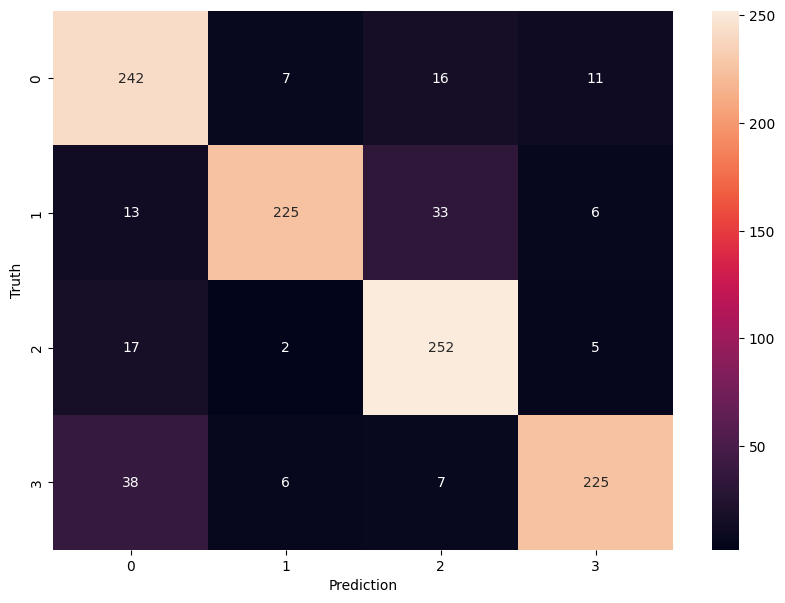

In [45]:

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')